# Subcategory Classification with EfficientNetB0

## Run this notebook to train the model, then save it for use in classification.py

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

## 2. Load and Combine Categories

In [ ]:
# Load data
df = pd.read_csv('../raw_data/articles_filtered.csv')
images_base = '../raw_data/images_filtered'

📂 Loading data...
Original data: 5156 rows


In [ ]:
# Combine similar categories
category_mapping = {
    'Heeled sandals': 'Heels',
    'Pumps': 'Heels',
    'Flat shoes': 'Flat shoe',
    'Moccasins': 'Flat shoe',
    'Ballerinas': 'Flat shoe',
    'Bootie': 'Boots',
}

df['product_type_name'] = df['product_type_name'].replace(category_mapping)

# Drop confusing categories
df = df[df['product_type_name'] != 'Other shoe']
df = df[df['product_type_name'] != 'Pre-walkers']

# Drop categories with too few samples (< 200)
value_counts = df['product_type_name'].value_counts()
rare_classes = value_counts[value_counts < 200].index.tolist()
df = df[~df['product_type_name'].isin(rare_classes)]

print(f"\n📊 Category distribution after combining:")
print(df['product_type_name'].value_counts())
print(f"\nTotal images: {len(df)}")
print(f"Number of categories: {df['product_type_name'].nunique()}")


📊 Category distribution after combining:
product_type_name
Sneakers     1573
Boots        1059
Sandals       733
Flat shoe     519
Heels         408
Slippers      244
Name: count, dtype: int64

Total images: 4536
Number of categories: 6


In [ ]:
# Get image paths using helper function
from shoppingassistant.helper_functions import get_image_path

def get_image_path_safe(article_id):
    try:
        return get_image_path(article_id)
    except:
        return None

df['image_path'] = df['article_id'].apply(get_image_path_safe)
df = df.dropna(subset=['image_path'])

print(f"Images found: {len(df)}")

✅ Images found: 4536


## 3. Create Category List 

In [5]:
# Get sorted list of categories
categories = sorted(df['product_type_name'].unique())
num_classes = len(categories)

print(f"\n🏷️ Categories ({num_classes}): {categories}")

# Create simple mapping
category_to_idx = {cat: idx for idx, cat in enumerate(categories)}
print(f"\nCategory mapping: {category_to_idx}")


🏷️ Categories (6): ['Boots', 'Flat shoe', 'Heels', 'Sandals', 'Slippers', 'Sneakers']

Category mapping: {'Boots': 0, 'Flat shoe': 1, 'Heels': 2, 'Sandals': 3, 'Slippers': 4, 'Sneakers': 5}


In [ ]:
# Add label column
df['label'] = df['product_type_name'].map(category_to_idx)

✅ Labels created


## 4. Split Data

In [ ]:
# Split data: 80% train, 10% val, 10% test
train_val_df, test_df = train_test_split(
    df, test_size=0.1, stratify=df['label'], random_state=42
)

train_df, val_df = train_test_split(
    train_val_df, test_size=0.11, stratify=train_val_df['label'], random_state=42
)

print(f"  Data split:")
print(f"  Train: {len(train_df)} images")
print(f"  Val:   {len(val_df)} images")
print(f"  Test:  {len(test_df)} images")


📊 Data split:
  Train: 3632 images
  Val:   450 images
  Test:  454 images


In [ ]:
# Compute class weights
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weights = dict(enumerate(class_weights_array))


⚖️ Class weights computed


## 5. Data Generators with EfficientNet Preprocessing

In [ ]:
target_size = (224, 224)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col='image_path', y_col='product_type_name',
    target_size=target_size, class_mode='sparse', batch_size=32, shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='product_type_name',
    target_size=target_size, class_mode='sparse', batch_size=32, shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='product_type_name',
    target_size=target_size, class_mode='sparse', batch_size=32, shuffle=False
)

Found 3632 validated image filenames belonging to 6 classes.
Found 450 validated image filenames belonging to 6 classes.
Found 454 validated image filenames belonging to 6 classes.
✅ Generators created


## 6. Build Model

In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=target_size + (3,)
)
base_model.trainable = False

inputs = layers.Input(shape=target_size + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model built and compiled")

🏗️ Building EfficientNetB0 model...
✅ Model built and compiled!


## 7. Train Model

In [11]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        '../models/subcategory_classifier_best.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    )
]

print("🚀 Training started...\n")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    class_weight=class_weights,
    callbacks=callbacks
)

print("\n✅ Training complete!")

🚀 Training started...

Epoch 1/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.5736 - loss: 1.2474
Epoch 1: val_accuracy improved from None to 0.79778, saving model to ../models/subcategory_classifier_best.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 57s 473ms/step - accuracy: 0.6649 - loss: 0.9993 - val_accuracy: 0.7978 - val_loss: 0.5891
Epoch 2/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 745ms/step - accuracy: 0.7711 - loss: 0.6716
Epoch 2: val_accuracy improved from 0.79778 to 0.81333, saving model to ../models/subcategory_classifier_best.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 95s 832ms/step - accuracy: 0.7662 - loss: 0.6965 - val_accuracy: 0.8133 - val_loss: 0.5254
Epoch 3/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step - accuracy: 0.8099 - loss: 0.5605
Epoch 3: val_accuracy improved from 0.81333 to 0.84000, saving model to ../models/subcategory_classifier_best.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 96s 840ms/step - accuracy: 0.7987 - loss: 0.5779 - val_accuracy: 0.8400 - val_loss: 0.4496
Epoch 4/

## 8. Evaluate

In [12]:
test_loss, test_acc = model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 334ms/step - accuracy: 0.8238 - loss: 0.5654
Test Accuracy: 0.8238 (82.38%)


In [13]:
y_true = test_generator.labels
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=categories))

15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 490ms/step
Classification Report:
              precision    recall  f1-score   support

       Boots       0.84      0.86      0.85       106
   Flat shoe       0.71      0.77      0.74        52
       Heels       0.83      0.95      0.89        41
     Sandals       0.88      0.70      0.78        73
    Slippers       0.57      0.50      0.53        24
    Sneakers       0.86      0.89      0.88       158

    accuracy                           0.82       454
   macro avg       0.78      0.78      0.78       454
weighted avg       0.82      0.82      0.82       454



## 9. Plot

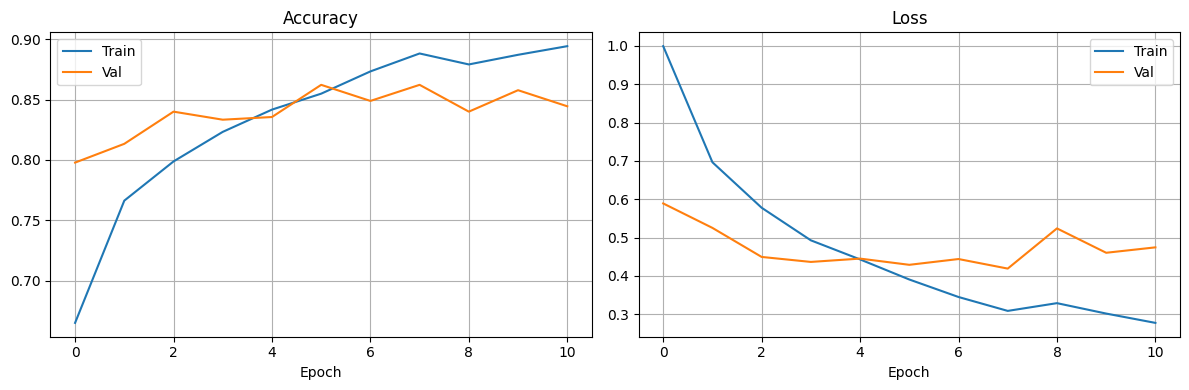

Best val accuracy: 0.8622 at epoch 6


In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val_acc = max(history.history['val_accuracy'])
print(f"Best val accuracy: {best_val_acc:.4f} at epoch {best_epoch}")

## 10. Test Prediction

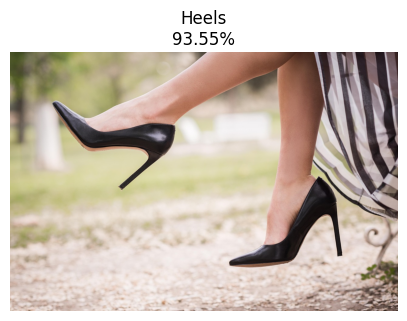


🔮 Prediction: Heels
   Confidence: 93.55%


In [17]:
# Test on web image
import requests
from PIL import Image
from io import BytesIO
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import load_model

# Load model
model = load_model('../models/subcategory_classifier_best.keras')

# Download test image
url = "https://cdn.pixabay.com/photo/2017/07/25/14/50/shoes-2538424_1280.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Preprocess
img_resized = img.resize((224, 224))
img_array = img_to_array(img_resized)
img_array = preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)
predicted_idx = np.argmax(prediction[0])
confidence = prediction[0][predicted_idx]
categories = ['Boots', 'Flat shoe', 'Heels', 'Sandals', 'Slippers', 'Sneakers']
predicted_category = categories[predicted_idx]

# Display
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"{predicted_category}\n{confidence:.2%}")
plt.axis('off')
plt.show()

print(f"\n🔮 Prediction: {predicted_category}")
print(f"   Confidence: {confidence:.2%}")

### Files saved:
- `../models/subcategory_classifier_best.keras` ← The model

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from shoppingassistant.helper_functions import preprocess_single_image
from shoppingassistant.params import *
import numpy as np
import os


def classify_subcategory(image_path, model=None):
    """
    Classifies the subcategory using EfficientNet model
    Categories are hardcoded - must match training order!
    """
    # Hardcoded categories (alphabetically sorted from training)
    categories = ['Boots', 'Flat shoe', 'Heels', 'Sandals', 'Slippers', 'Sneakers']

    # Load model
    if model is None:
        model = load_model(os.path.join(BASE_DIR, 'models', 'subcategory_classifier_best.keras'))

    # Preprocess with EfficientNet
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    predicted_category = categories[predicted_idx]

    return predicted_category


def classify_gender(image_path, model=None):
    '''
    Classifies the gender
    '''
    categories = ['Baby/Children', 'Ladieswear', 'Menswear']
    img_array = preprocess_single_image(image_path)

    predictions = model.predict(img_array, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    predicted_gender = categories[predicted_idx]

    return predicted_gender